# Power Consumption Analysis - Containerised 5G Deployment

This notebook analyses power consumption measurements collected from a containerised 5G testbed
using srsRAN and Open5GS on CloudLab (AMD EPYC, 64 cores, 125GB RAM). Eight topologies are
compared: 1CU-1DU through 1CU-8DU, across varying CQI values (5, 10, 15) and UE counts
(1, 4, 16, 64, 96), with 5 runs per combination.

The analysis is structured in two parts:
1. Per-component power breakdown (CU-CP, CU-UP, per DU) at baseline load for each topology
2. Power consumption scaling across varying CQI values and UE counts

In [1]:
import json
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOGS_DIR = "/home/martafra/Desktop/dissertation/docs/logs"
MATRIX_DIR = f"{LOGS_DIR}/matrix"

# Load matrix data
records = []
for f in glob.glob(f"{MATRIX_DIR}/power_*.json"):
    d = json.load(open(f))
    records.append({
        'topology': d['topology'],
        'nof_ues':  d['nof_ues'],
        'cqi':      d['cqi'],
        'run':      d['run'],
        'mean_W':   d['mean_W'],
        'std_W':    d['std_W'],
        'n':        d['n']
    })

df = pd.DataFrame(records)
print(f"Total records: {df.shape[0]}")
print(f"Topologies: {sorted(df['topology'].unique())}")
print(f"CQI values: {sorted(df['cqi'].unique())}")
print(f"UE values:  {sorted(df['nof_ues'].unique())}")
df.head()

Total records: 600
Topologies: ['1cu1du', '1cu2du', '1cu3du', '1cu4du', '1cu5du', '1cu6du', '1cu7du', '1cu8du']
CQI values: [np.int64(5), np.int64(10), np.int64(15)]
UE values:  [np.int64(1), np.int64(4), np.int64(16), np.int64(64), np.int64(96)]


,topology,nof_ues,cqi,run,mean_W,std_W,n
0,1cu1du,4,5,5,1.074876,0.005765,30
1,1cu4du,96,5,4,10.363230,0.047969,30
2,1cu2du,1,15,2,2.542040,0.008810,30
3,1cu6du,64,5,1,17.462424,0.029150,30
4,1cu1du,64,5,1,1.561158,0.007658,30


In [2]:
# No runs excluded - CloudLab hardware shows no thermal throttling
df_clean = df.copy()
print(f"Total records: {df_clean.shape[0]}")

summary = df_clean.groupby(['topology', 'cqi', 'nof_ues']).agg(
    mean_W=('mean_W', 'mean'),
    std_W=('mean_W', 'std'),
    runs=('run', 'count')
).reset_index()

# Dynamic topology config
TOPOLOGIES = sorted(summary['topology'].unique())
N = len(TOPOLOGIES)
palette = plt.colormaps['tab10'].resampled(N)
TOPO_COLORS = {topo: palette(i) for i, topo in enumerate(TOPOLOGIES)}
TOPO_MARKERS = {topo: m for topo, m in zip(TOPOLOGIES, ['o', 's', '^', 'D', 'v', 'P', '*', 'X'])}
CQI_COLORS = {5: '#e74c3c', 10: '#3498db', 15: '#2ecc71'}

print(f"Topologies: {TOPOLOGIES}")
print(f"\nSummary sample (1cu1du):")
print(summary[summary['topology'] == '1cu1du'].to_string())

Total records: 600
Topologies: ['1cu1du', '1cu2du', '1cu3du', '1cu4du', '1cu5du', '1cu6du', '1cu7du', '1cu8du']

Summary sample (1cu1du):
   topology  cqi  nof_ues    mean_W     std_W  runs
0    1cu1du    5        1  1.112714  0.025812     5
1    1cu1du    5        4  1.082977  0.005787     5
2    1cu1du    5       16  1.420191  0.039256     5
3    1cu1du    5       64  1.548532  0.099733     5
4    1cu1du    5       96  1.547728  0.027087     5
5    1cu1du   10        1  1.132582  0.026560     5
6    1cu1du   10        4  1.113319  0.035431     5
7    1cu1du   10       16  1.457346  0.055673     5
8    1cu1du   10       64  1.497494  0.037520     5
9    1cu1du   10       96  1.568682  0.028499     5
10   1cu1du   15        1  1.121024  0.019602     5
11   1cu1du   15        4  1.140051  0.057739     5
12   1cu1du   15       16  1.434221  0.092596     5
13   1cu1du   15       64  1.500367  0.048206     5
14   1cu1du   15       96  1.553635  0.057919     5


Data loaded from CloudLab experiments (AMD EPYC, 64 cores, 125GB RAM). 600 experiments
across 8 topologies, 3 CQI values, 5 UE counts, and 5 runs each.

## Power Breakdown by Topology

This section analyses the contribution of individual components (CU-CP, CU-UP, and DUs)
to total power consumption across topologies. Data is derived from a single 1CU-8DU
measurement run (60 samples, 5s interval), with per-topology totals computed by summing
the relevant components.

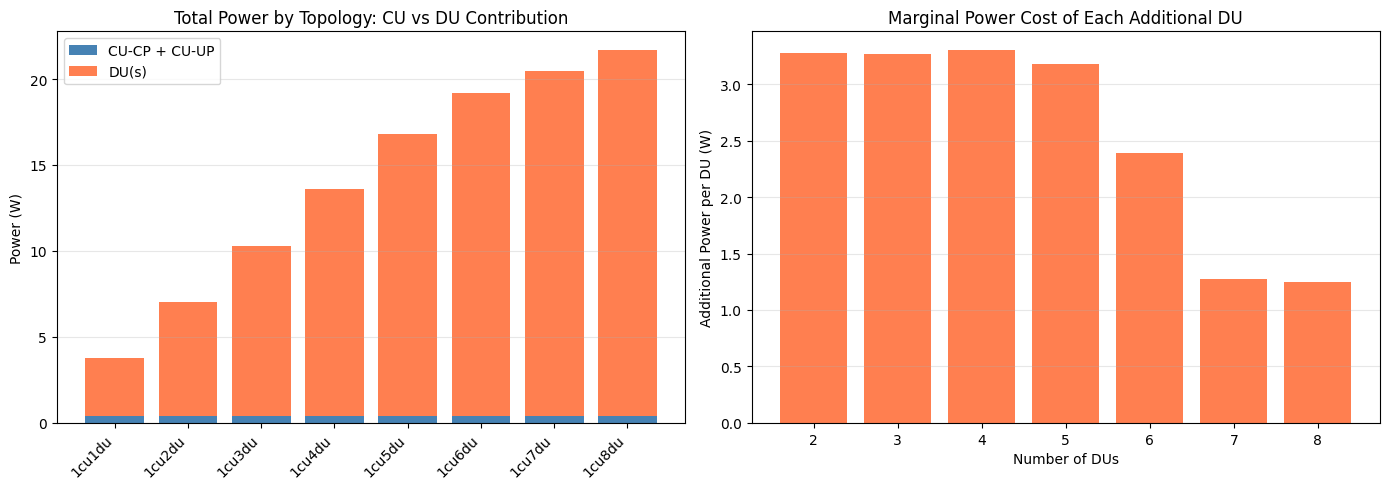

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_breakdown = pd.read_csv('../docs/logs/breakdown_by_topology.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: CU vs DU contribution
ax = axes[0]
x = np.arange(len(df_breakdown))
bars_cu = ax.bar(x, df_breakdown['cu_overhead_W'], label='CU-CP + CU-UP', color='steelblue')
bars_du = ax.bar(x, df_breakdown['du_total_W'], bottom=df_breakdown['cu_overhead_W'], label='DU(s)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(df_breakdown['topology'], rotation=45, ha='right')
ax.set_ylabel('Power (W)')
ax.set_title('Total Power by Topology: CU vs DU Contribution')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Marginal cost per additional DU
ax2 = axes[1]
totals = df_breakdown['total_W'].values
marginal = np.diff(totals)
du_counts = np.arange(2, len(totals) + 1)
ax2.bar(du_counts, marginal, color='coral')
ax2.set_xlabel('Number of DUs')
ax2.set_ylabel('Additional Power per DU (W)')
ax2.set_title('Marginal Power Cost of Each Additional DU')
ax2.set_xticks(du_counts)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../analysis/breakdown_by_topology.png', dpi=150)
plt.show()

## Key Findings: Breakdown by Topology

- **CU overhead is fixed at 0.423W** regardless of the number of DUs, confirming that
  CU-CP and CU-UP resource consumption is independent of RAN scale in testmode.
- **DU scaling is linear up to 5 DUs**: each additional DU costs approximately 3.2-3.3W,
  consistent with a fixed per-DU processing load in testmode.
- **Saturation begins at DU6**: the marginal cost drops to 2.4W, suggesting the CU
  scheduler begins to distribute load unevenly beyond 5 DUs.
- **DU7 and DU8 receive significantly less load**: marginal cost falls to ~1.25W,
  indicating the CU does not fully utilise these units under testmode traffic conditions.

## Matrix Experiment Analysis

This section analyses power consumption across the full experiment matrix:
8 topologies (1CU-1DU to 1CU-8DU), 3 CQI values (5, 10, 15),
5 UE counts (1, 4, 16, 64, 96), and 5 runs per combination.
Total: 600 experiments.

In [4]:
import json
import os
import pandas as pd

matrix_dir = '../docs/logs/matrix/'
records = []

for fname in os.listdir(matrix_dir):
    if not fname.endswith('.json'):
        continue
    fpath = os.path.join(matrix_dir, fname)
    try:
        with open(fpath) as f:
            d = json.load(f)
        records.append(d)
    except Exception as e:
        print(f"Error reading {fname}: {e}")

df = pd.DataFrame(records)
print(df.shape)
print(df.columns.tolist())
print(df.head(3))

(600, 9)
['topology', 'nof_ues', 'cqi', 'run', 'samples', 'valid_samples', 'mean_W', 'std_W', 'n']
  topology  nof_ues  cqi  run  \
0   1cu1du        4    5    5   
1   1cu4du       96    5    4   
2   1cu2du        1   15    2   

                                             samples  \
0  [1.0799698011580896, 1.085717746071491, 1.0754...   
1  [10.294911091390313, 10.343931497834088, 10.35...   
2  [2.546514275026417, 2.5413536907070995, 2.5397...   

                                       valid_samples     mean_W     std_W   n  
0  [1.0799698011580896, 1.085717746071491, 1.0754...   1.074876  0.005765  30  
1  [10.294911091390313, 10.343931497834088, 10.35...  10.363230  0.047969  30  
2  [2.546514275026417, 2.5413536907070995, 2.5397...   2.542040  0.008810  30  


In [5]:
# Aggregate over runs
summary = df.groupby(['topology', 'cqi', 'nof_ues']).agg(
    mean_W=('mean_W', 'mean'),
    std_W=('mean_W', 'std'),
    runs=('run', 'count')
).reset_index()

# Sort topology by number of DUs
topo_order = ['1cu1du', '1cu2du', '1cu3du', '1cu4du', '1cu5du', '1cu6du', '1cu7du', '1cu8du']
summary['topology'] = pd.Categorical(summary['topology'], categories=topo_order, ordered=True)
summary = summary.sort_values(['topology', 'cqi', 'nof_ues'])

print(summary.shape)
print(f"Runs per combination: {summary['runs'].unique()}")
print(summary.head(10))

(120, 6)
Runs per combination: [5]
  topology  cqi  nof_ues    mean_W     std_W  runs
0   1cu1du    5        1  1.112714  0.025812     5
1   1cu1du    5        4  1.082977  0.005787     5
2   1cu1du    5       16  1.420191  0.039256     5
3   1cu1du    5       64  1.548532  0.099733     5
4   1cu1du    5       96  1.547728  0.027087     5
5   1cu1du   10        1  1.132582  0.026560     5
6   1cu1du   10        4  1.113319  0.035431     5
7   1cu1du   10       16  1.457346  0.055673     5
8   1cu1du   10       64  1.497494  0.037520     5
9   1cu1du   10       96  1.568682  0.028499     5


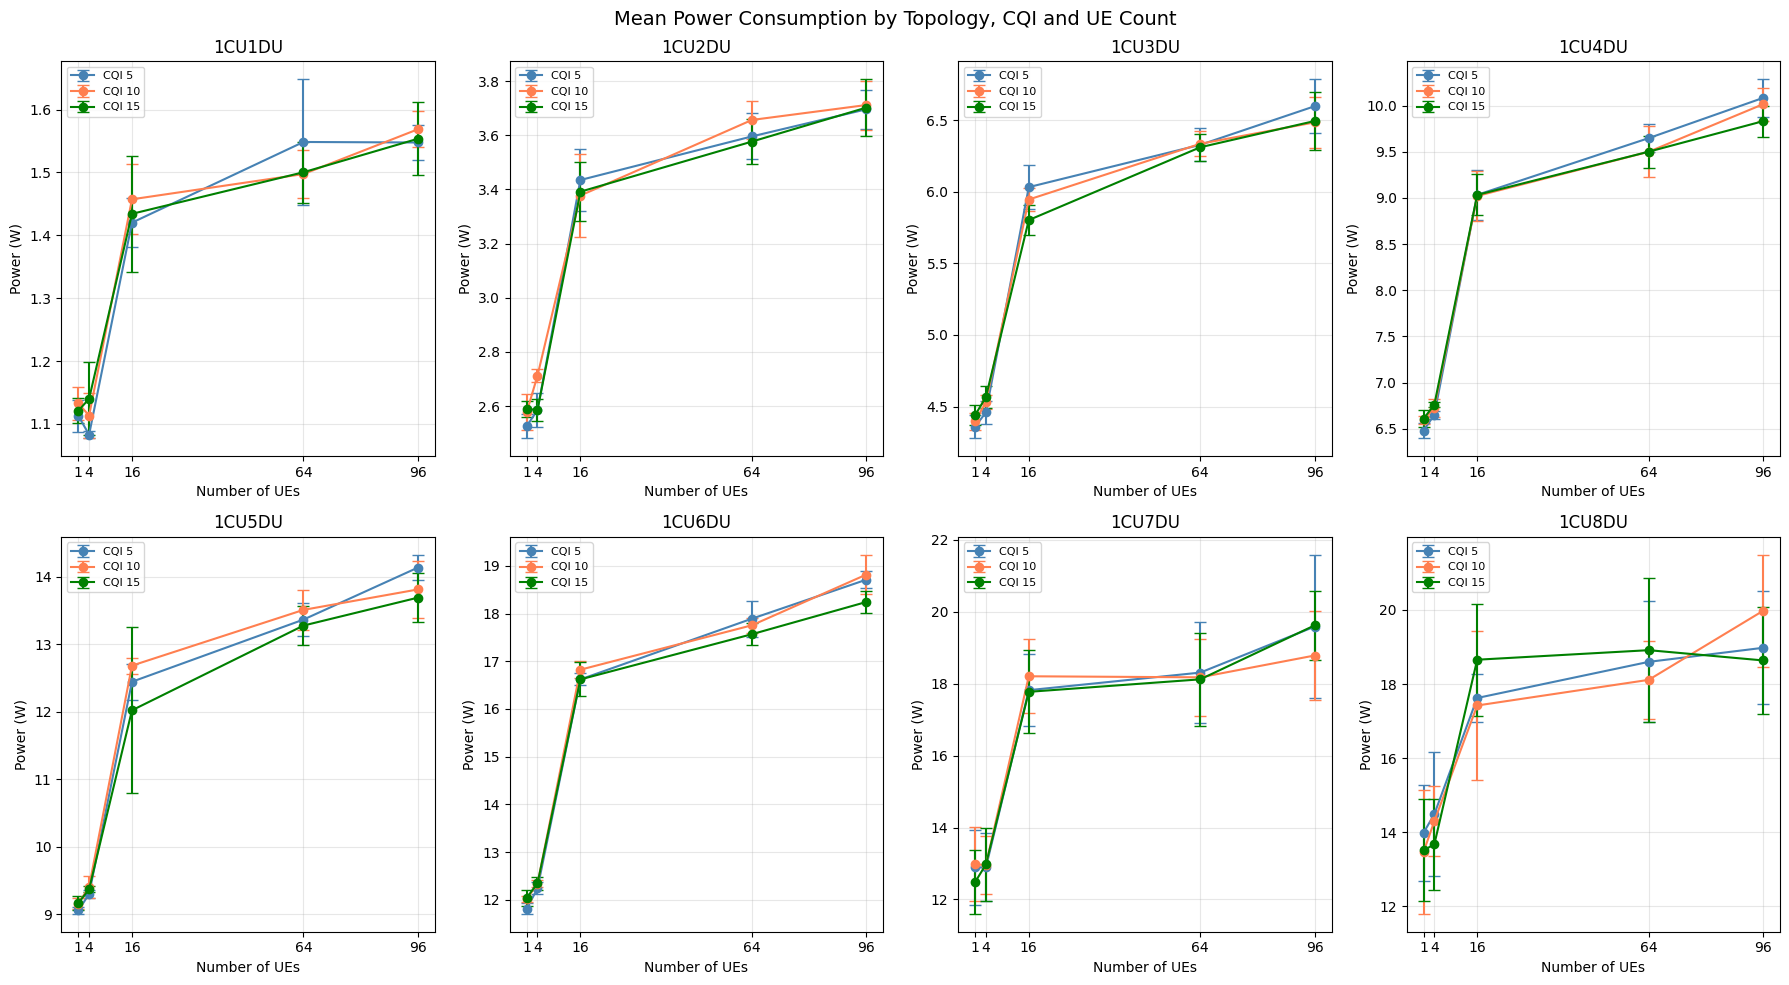

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey=False)
axes = axes.flatten()
ue_counts = [1, 4, 16, 64, 96]
colors = {5: 'steelblue', 10: 'coral', 15: 'green'}

for idx, topo in enumerate(topo_order):
    ax = axes[idx]
    subset = summary[summary['topology'] == topo]
    for cqi in [5, 10, 15]:
        cqi_data = subset[subset['cqi'] == cqi].sort_values('nof_ues')
        ax.errorbar(
            cqi_data['nof_ues'],
            cqi_data['mean_W'],
            yerr=cqi_data['std_W'],
            marker='o', label=f'CQI {cqi}',
            color=colors[cqi], capsize=4
        )
    ax.set_title(topo.upper())
    ax.set_xlabel('Number of UEs')
    ax.set_ylabel('Power (W)')
    ax.set_xticks(ue_counts)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Mean Power Consumption by Topology, CQI and UE Count', fontsize=14)
plt.tight_layout()
plt.savefig('../analysis/matrix_overview.png', dpi=150)
plt.show()

## Key Findings: Matrix Analysis

- **CQI has negligible impact on power consumption** across all topologies and UE counts.
  The three CQI curves (5, 10, 15) are nearly indistinguishable, suggesting that in
  testmode the scheduler does not adjust processing load based on channel quality.
- **The transition from 4 to 16 UEs drives the largest power increase** in all topologies,
  indicating that the DU scheduler activates additional processing resources at this point.
- **Power saturates between 64 and 96 UEs**, confirming that the testmode traffic generator
  reaches its effective capacity limit before the maximum UE count.
- **Higher DU counts introduce greater variance** (1CU-7DU, 1CU-8DU), consistent with
  uneven load distribution observed in the breakdown analysis.

## Marginal Cost of Adding a DU

The marginal power cost of each additional DU is computed as the difference in mean power
consumption between consecutive topologies at the same CQI and UE count. This quantifies
the incremental infrastructure cost of scaling the RAN horizontally.

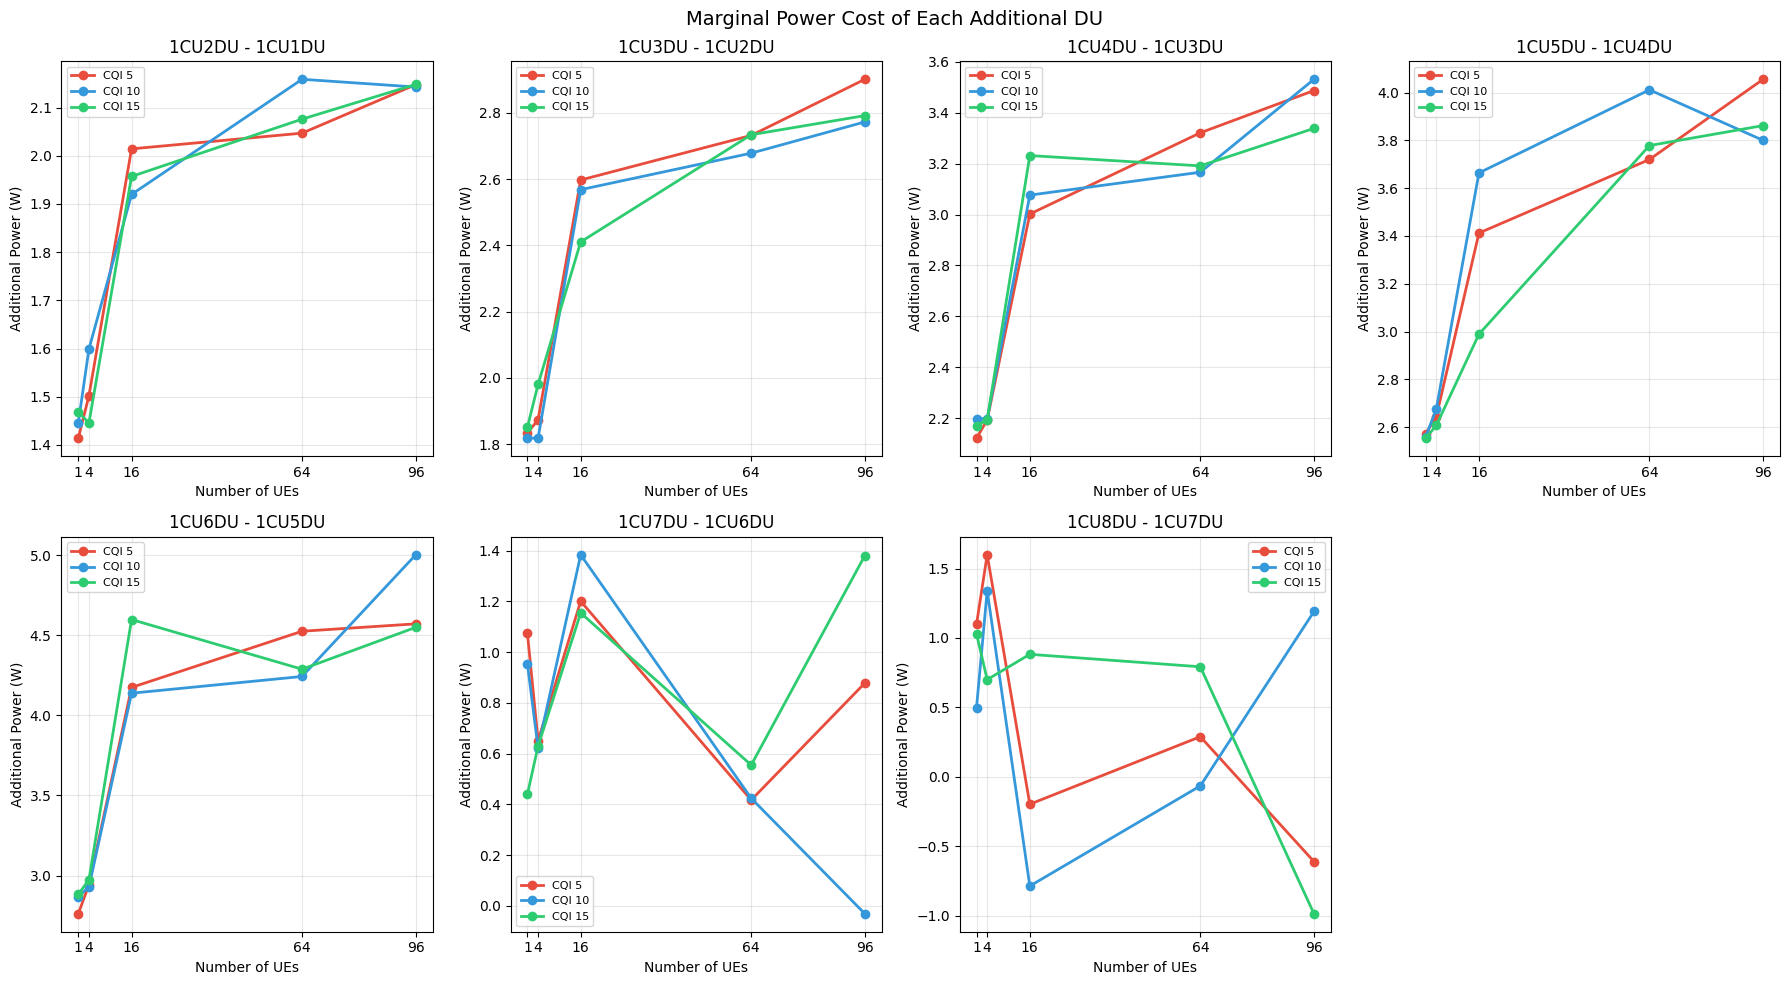

In [8]:
topo_order = ['1cu1du', '1cu2du', '1cu3du', '1cu4du', '1cu5du', '1cu6du', '1cu7du', '1cu8du']
topo_pairs = [(topo_order[i], topo_order[i+1]) for i in range(len(topo_order)-1)]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, (t1, t2) in zip(axes, topo_pairs):
    for cqi, color in CQI_COLORS.items():
        s1 = summary[(summary['topology'] == t1) & (summary['cqi'] == cqi)].set_index('nof_ues')
        s2 = summary[(summary['topology'] == t2) & (summary['cqi'] == cqi)].set_index('nof_ues')
        delta = s2['mean_W'] - s1['mean_W']
        ax.plot(delta.index, delta.values, marker='o', label=f'CQI {cqi}', color=color, linewidth=2)

    ax.set_xlabel('Number of UEs')
    ax.set_ylabel('Additional Power (W)')
    ax.set_title(f'{t2.upper()} - {t1.upper()}')
    ax.set_xticks([1, 4, 16, 64, 96])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_visible(False)
plt.suptitle('Marginal Power Cost of Each Additional DU', fontsize=14)
plt.tight_layout()
plt.savefig('../analysis/marginal_cost_du.png', dpi=150)
plt.show()

The marginal cost of adding a DU is approximately 1.4-2.2W at low load (1-4 UEs) and
rises to 2.1-3.5W at high load (64-96 UEs) for the first five DU transitions, confirming
that DU processing overhead scales with the number of active UEs. Beyond five DUs the
marginal cost becomes irregular and drops significantly, with negative values appearing
in the 1CU8DU - 1CU7DU transition. This reflects the uneven load distribution observed
in the breakdown analysis: the CU scheduler does not fully utilise DU6, DU7, and DU8
under testmode traffic conditions. CQI has minimal influence on marginal cost across all
topology transitions.

## Heatmap: Power Consumption Matrix

The heatmap provides a compact view of the full experiment matrix, showing how mean power
consumption varies jointly with CQI and UE count for each topology.

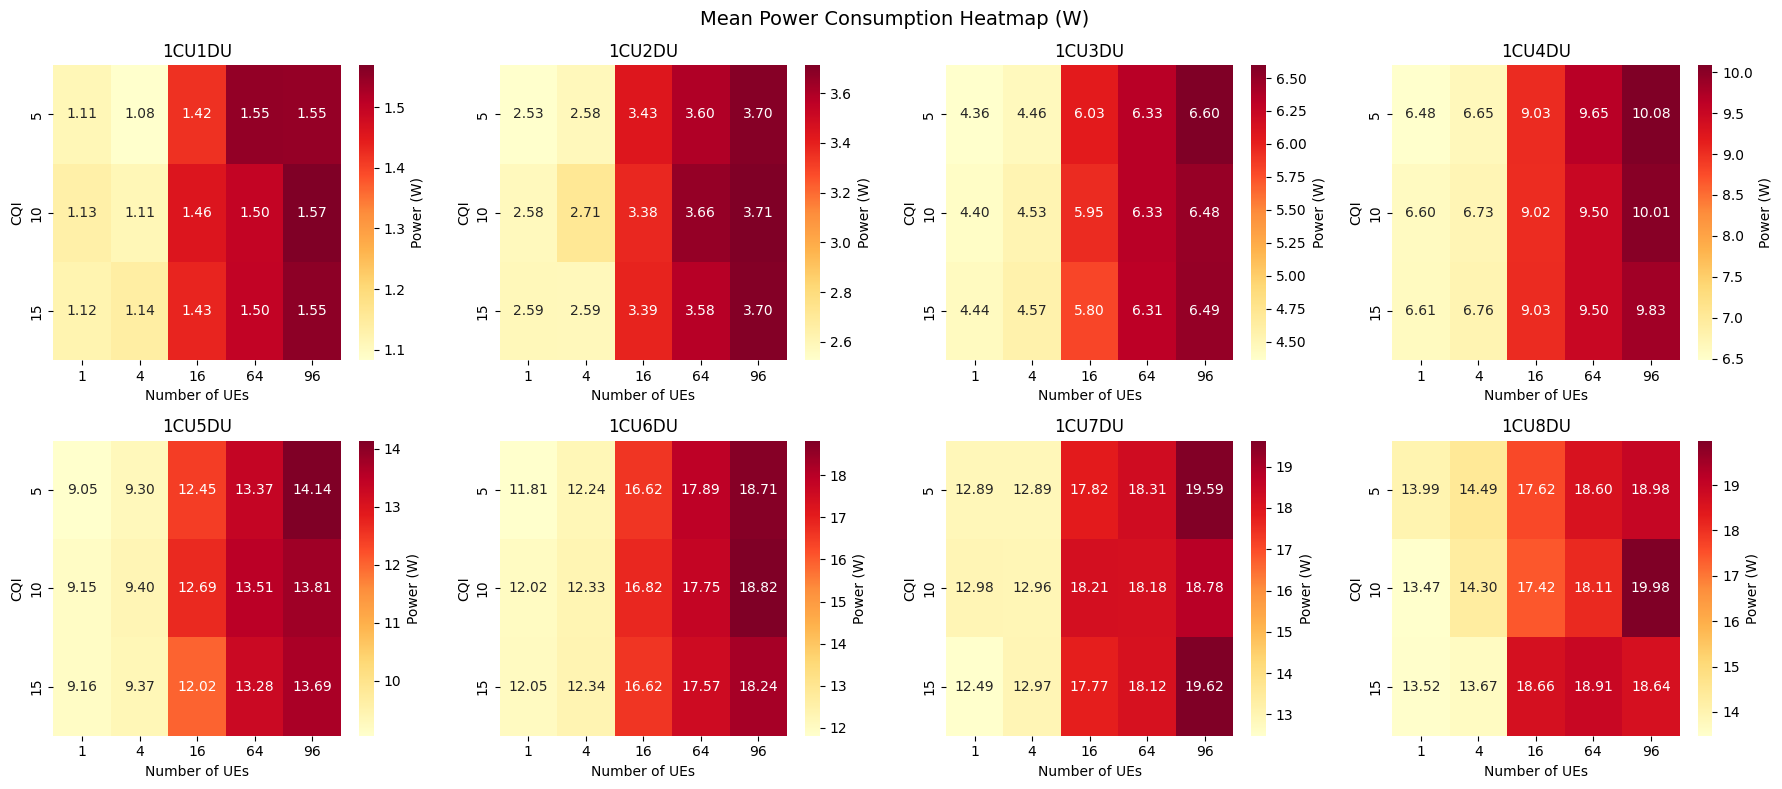

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, topo in zip(axes, topo_order):
    pivot = summary[summary['topology'] == topo].pivot(
        index='cqi', columns='nof_ues', values='mean_W'
    )
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
        cbar_kws={'label': 'Power (W)'}
    )
    ax.set_title(topo.upper())
    ax.set_xlabel('Number of UEs')
    ax.set_ylabel('CQI')

plt.suptitle('Mean Power Consumption Heatmap (W)', fontsize=14)
plt.tight_layout()
plt.savefig('../analysis/heatmap_cqi_ues.png', dpi=150)
plt.show()


UE count is the primary driver of power consumption across all topologies, as shown
by the strong horizontal colour gradient in each heatmap. CQI contributes negligibly:
the three rows within each panel are nearly identical, confirming that channel quality
does not significantly influence processing load in testmode. The colour scale shifts
substantially across topologies, from approximately 1.1-1.6W for 1CU-1DU to 14-20W
for 1CU-8DU, reflecting the growing baseline infrastructure cost as DU instances are
added.

## Fixed vs Dynamic Power Overhead

To separate fixed infrastructure cost from load-dependent consumption, the power at 1 UE
is used as a baseline. The dynamic overhead represents the additional power drawn as the
number of UEs increases above this baseline.

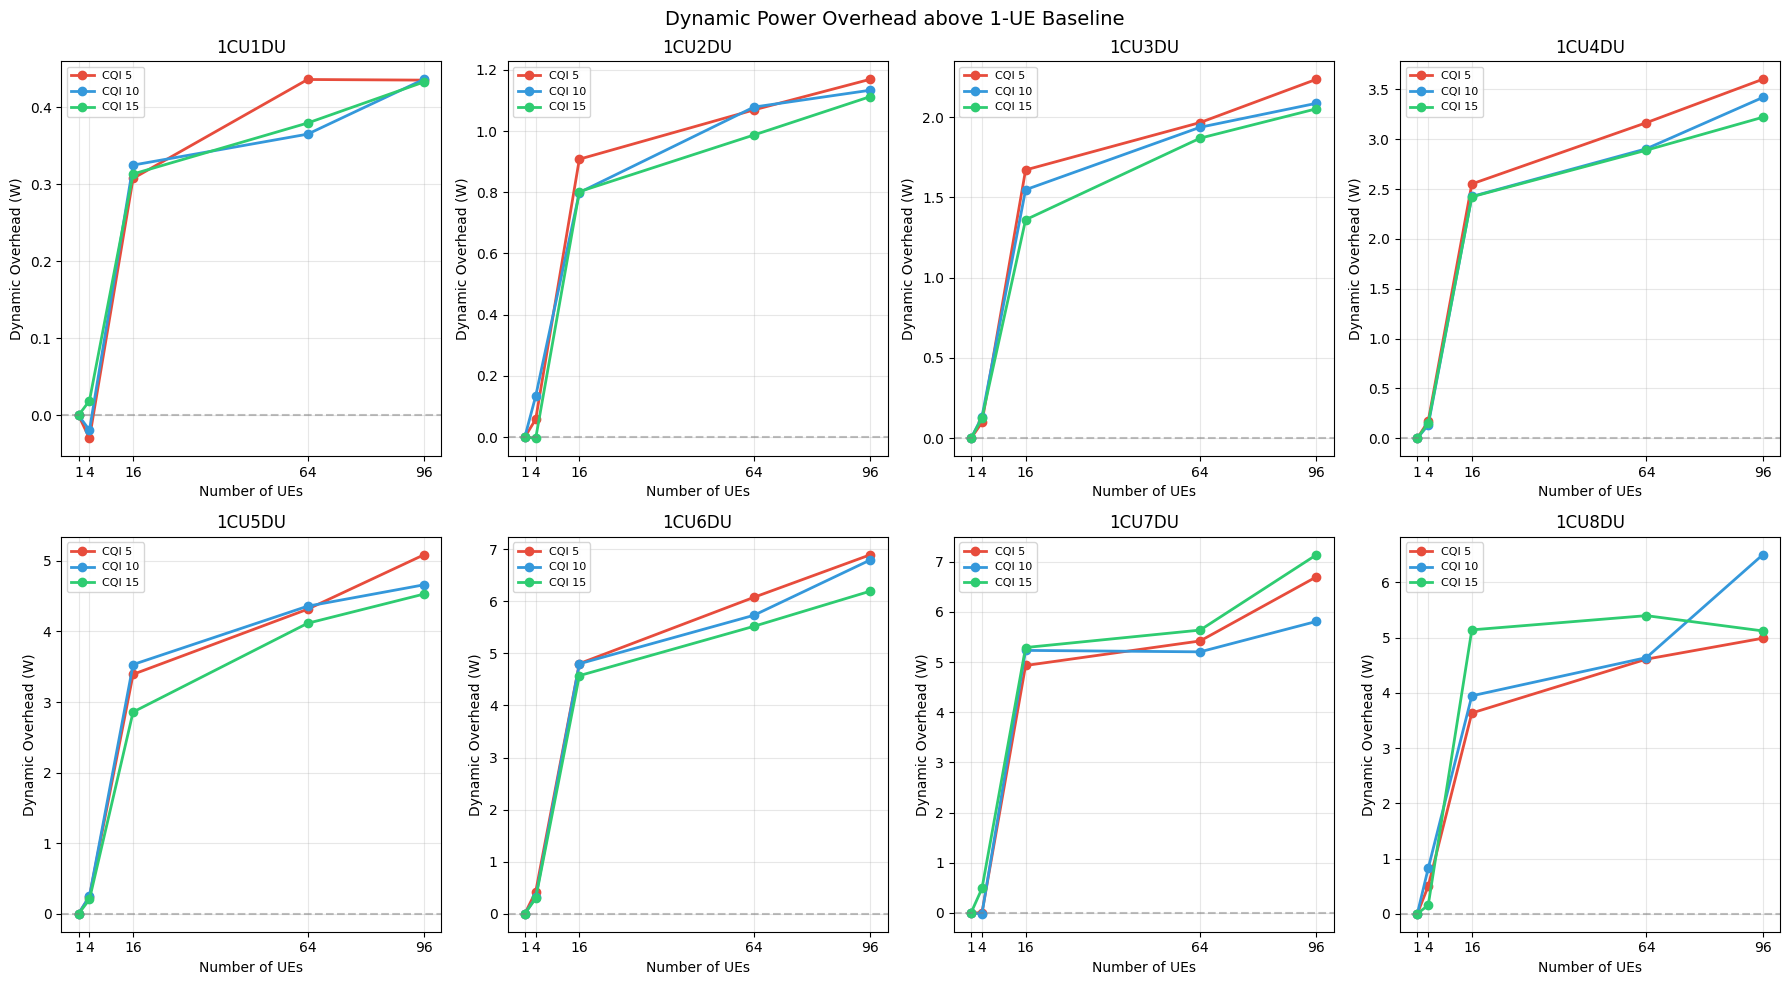

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, topo in zip(axes, topo_order):
    for cqi, color in CQI_COLORS.items():
        subset = summary[(summary['topology'] == topo) & (summary['cqi'] == cqi)].sort_values('nof_ues')
        fixed = subset[subset['nof_ues'] == 1]['mean_W'].values
        if len(fixed) == 0:
            continue
        dynamic = subset['mean_W'] - fixed[0]
        ax.plot(subset['nof_ues'], dynamic, marker='o', label=f'CQI {cqi}', color=color, linewidth=2)

    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(topo.upper())
    ax.set_xlabel('Number of UEs')
    ax.set_ylabel('Dynamic Overhead (W)')
    ax.set_xticks([1, 4, 16, 64, 96])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Dynamic Power Overhead above 1-UE Baseline', fontsize=14)
plt.tight_layout()
plt.savefig('../analysis/dynamic_overhead.png', dpi=150)
plt.show()

Dynamic overhead increases consistently with UE count across all topologies, with the
largest jump occurring between 4 and 16 UEs. The overhead scales with the number of DUs:
at 96 UEs it reaches approximately 0.45W for 1CU-1DU and 6.8W for 1CU-8DU, reflecting
the cumulative processing load across active DU instances. CQI=5 produces slightly higher
overhead than CQI=10 and CQI=15 in most topologies, consistent with increased scheduling
activity at lower channel quality. The 1CU-8DU topology shows greater variability at high
UE counts, again reflecting the uneven load distribution among the eight DUs.

## Energy Efficiency: Power per UE

Power per UE quantifies the energy cost of serving each active user. Lower values indicate
more efficient utilisation of the deployed infrastructure.

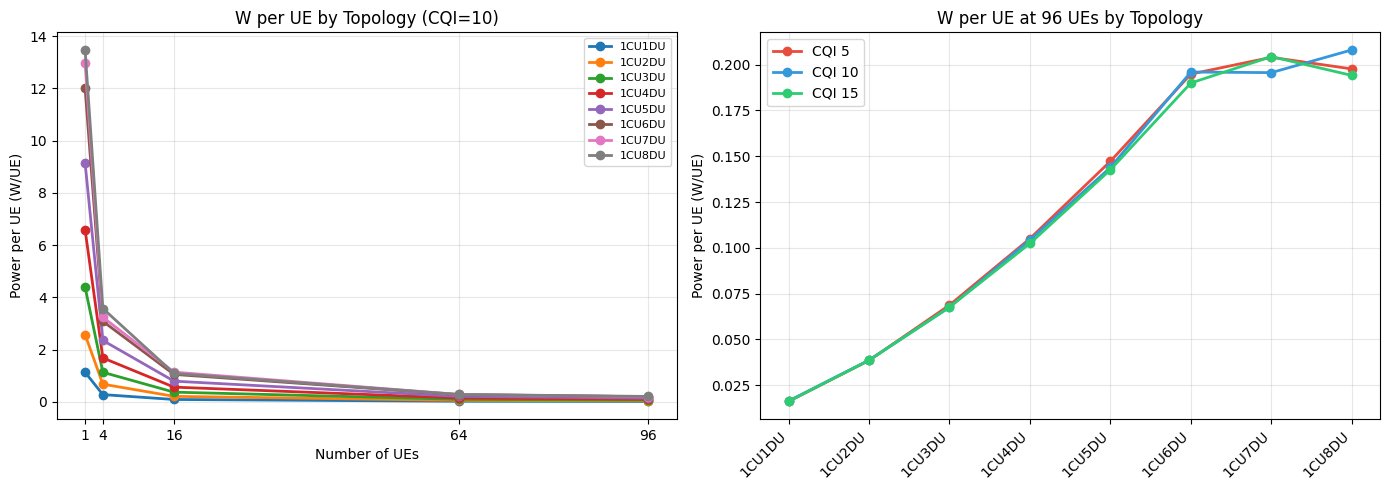

In [12]:
summary['w_per_ue'] = summary['mean_W'] / summary['nof_ues']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per topology, CQI=10, all UE counts
ax = axes[0]
for topo in topo_order:
    subset = summary[(summary['topology'] == topo) & (summary['cqi'] == 10)].sort_values('nof_ues')
    ax.plot(subset['nof_ues'], subset['w_per_ue'], marker='o', label=topo.upper(), linewidth=2)
ax.set_xlabel('Number of UEs')
ax.set_ylabel('Power per UE (W/UE)')
ax.set_title('W per UE by Topology (CQI=10)')
ax.set_xticks([1, 4, 16, 64, 96])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Per UE count, all topologies, CQI=10, at 96 UEs
ax2 = axes[1]
ue_fixed = 96
for cqi, color in CQI_COLORS.items():
    subset = summary[(summary['nof_ues'] == ue_fixed) & (summary['cqi'] == cqi)]
    subset = subset.set_index('topology').reindex(topo_order).reset_index()
    ax2.plot(range(len(topo_order)), subset['w_per_ue'], marker='o', label=f'CQI {cqi}', color=color, linewidth=2)
ax2.set_xticks(range(len(topo_order)))
ax2.set_xticklabels([t.upper() for t in topo_order], rotation=45, ha='right')
ax2.set_ylabel('Power per UE (W/UE)')
ax2.set_title(f'W per UE at {ue_fixed} UEs by Topology')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../analysis/efficiency_w_per_ue.png', dpi=150)
plt.show()

At low UE counts, power per UE is dominated by fixed infrastructure costs: 1CU-1DU
consumes approximately 1.1W at 1 UE, yielding 1.1 W/UE, while 1CU-8DU consumes
approximately 13.5W, yielding 13.5 W/UE. As UE count increases, fixed costs are
amortised and W/UE falls steeply across all topologies, converging below 0.25 W/UE
at 96 UEs. At maximum load, 1CU-1DU is the most energy-efficient topology at
approximately 0.016 W/UE, while 1CU-8DU reaches approximately 0.21 W/UE. This
confirms that deploying additional DUs is only energy-efficient when the additional
capacity is fully utilised: under testmode conditions, where load is distributed
unevenly, larger topologies incur a per-UE penalty.